# WEEK 7: DIMENSIONALITY REDUCTION
## Implementing Feature Selection and PCA, Visualizing Variance

**Course:** Data Science & Visualization Lab

**Dataset:** movie_metadata_feature_engineered.csv (from Week 6)

---




## 1. Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.feature_selection import (
    SelectKBest,
    f_regression,
    mutual_info_regression,
    VarianceThreshold
)
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)



This cell imports essential libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), and machine learning (sklearn's PCA, feature selection methods, and RandomForestRegressor). It also configures plotting styles and suppresses warnings.

In [2]:
# Load feature engineered dataset from Week 6
df = pd.read_csv('movie_metadata_feature_engineered.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Features: {df.shape[1]}")
print(f"Samples: {df.shape[0]}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (5043, 43)
Features: 43
Samples: 5043

First 5 rows:


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,language_Mandarin,language_Other,language_Spanish,country_Canada,country_France,country_Germany,country_Other,country_UK,country_USA,director_frequency
0,Color,James Cameron,1.862156,2.278433,-1.573752,855.0,Joel David Moore,-0.322985,1.804738,Action|Adventure|Fantasy|Sci-Fi,...,False,False,False,False,False,False,False,False,True,0.001388
1,Color,Gore Verbinski,1.353991,2.278433,1.114253,1000.0,Orlando Bloom,1.843361,1.804738,Action|Adventure|Fantasy,...,False,False,False,False,False,False,False,False,True,0.001388
2,Color,Sam Mendes,1.862156,1.967736,-1.573752,161.0,Rory Kinnear,1.033220,1.804738,Action|Adventure|Thriller,...,False,False,False,False,False,False,False,True,False,0.001586
3,Color,Christopher Nolan,1.862156,2.278433,2.545966,23000.0,Christian Bale,1.590422,1.804738,Action|Thriller,...,False,False,False,False,False,False,False,False,True,0.001586
4,Color,Doug Walker,0.030605,-0.121323,0.522500,371.5,Rob Walker,-1.334427,-0.047649,Documentary,...,False,False,False,False,False,False,False,False,True,0.000198


This cell loads the movie metadata dataset, previously engineered in Week 6, into a pandas DataFrame. It then prints the dataset's dimensions (shape, number of features, and samples) and displays the initial five rows to provide a quick overview of the data structure.

In [3]:
# Check for numeric columns only (required for PCA)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {len(numeric_cols)}")
print(numeric_cols[:20])  # Show first 20

Numeric columns: 19
['num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes', 'color_encoded', 'content_rating_encoded', 'director_frequency']


This code identifies and extracts all numeric columns from the DataFrame, which are crucial for subsequent dimensionality reduction techniques. It then displays the count and the first 20 names of these identified numeric columns.

In [4]:
# Prepare data for dimensionality reduction
# Select only numeric features
df_numeric = df[numeric_cols].copy()

# Handle any remaining missing values
df_numeric = df_numeric.fillna(df_numeric.median())

print(f"Numeric dataset shape: {df_numeric.shape}")
print(f"Missing values: {df_numeric.isnull().sum().sum()}")

Numeric dataset shape: (5043, 19)
Missing values: 0


This cell prepares the data for dimensionality reduction by creating a subset containing only numeric features. It addresses any existing missing values by imputing them with the median of their respective columns, and then confirms the resulting dataset's shape and the absence of null values.

## 2. Understanding High-Dimensional Data

In [5]:
print("="*70)
print("DIMENSIONALITY ANALYSIS")
print("="*70)
print(f"\nTotal Features: {df_numeric.shape[1]}")
print(f"Total Samples: {df_numeric.shape[0]}")
print(f"Dimensionality Ratio: {df_numeric.shape[1]/df_numeric.shape[0]:.3f}")
print(f"\nCurse of Dimensionality Concerns:")
print(f"  - High computational cost")
print(f"  - Overfitting risk")
print(f"  - Sparse data in high dimensions")
print(f"  - Difficult visualization")

DIMENSIONALITY ANALYSIS

Total Features: 19
Total Samples: 5043
Dimensionality Ratio: 0.004

Curse of Dimensionality Concerns:
  - High computational cost
  - Overfitting risk
  - Sparse data in high dimensions
  - Difficult visualization


This cell provides a preliminary analysis of the dataset's dimensionality, reporting the total number of features and samples, and calculating the feature-to-sample ratio. It also outlines common challenges associated with high-dimensional data, such as increased computational cost and risk of overfitting.

## 3. Feature Selection Methods

### 3.1 Variance Threshold (Remove Low Variance Features)

In [6]:
print("="*70)
print("METHOD 1: VARIANCE THRESHOLD")
print("="*70)
print("Removes features with low variance (nearly constant)\n")

# Calculate variance for each feature
variances = df_numeric.var().sort_values()

print("Features with lowest variance:")
print(variances.head(10))

# Apply variance threshold
threshold = 0.01
selector = VarianceThreshold(threshold=threshold)
df_var_threshold = selector.fit_transform(df_numeric)

removed_features = df_numeric.shape[1] - df_var_threshold.shape[1]
print(f"\nVariance Threshold: {threshold}")
print(f"Features Removed: {removed_features}")
print(f"Features Remaining: {df_var_threshold.shape[1]}")

METHOD 1: VARIANCE THRESHOLD
Removes features with low variance (nearly constant)

Features with lowest variance:
director_frequency           0.000016
color_encoded                0.039734
imdb_score                   1.000198
movie_facebook_likes         1.000198
duration                     1.000198
actor_1_facebook_likes       1.000198
num_critic_for_reviews       1.000198
cast_total_facebook_likes    1.000198
num_voted_users              1.000198
gross                        1.000198
dtype: float64

Variance Threshold: 0.01
Features Removed: 1
Features Remaining: 18


This cell implements the Variance Threshold method for feature selection. It calculates the variance of each numeric feature and then removes features whose variance falls below a predefined threshold (0.01), as these features contribute little to data discrimination. The output includes the number of features removed and remaining.

### 3.2 Correlation-Based Feature Selection

In [7]:
print("\n" + "="*70)
print("METHOD 2: CORRELATION-BASED FEATURE SELECTION")
print("="*70)
print("Removes highly correlated features (redundant information)\n")

# Calculate correlation matrix
correlation_matrix = df_numeric.corr().abs()

# Find highly correlated pairs
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Find features with correlation > 0.9
to_drop = [column for column in upper_triangle.columns
           if any(upper_triangle[column] > 0.9)]

print(f"Highly correlated features (correlation > 0.9): {len(to_drop)}")
if to_drop:
    print(f"Features to drop: {to_drop[:10]}")  # Show first 10

# Remove highly correlated features
df_low_corr = df_numeric.drop(columns=to_drop)

print(f"\nFeatures after removing high correlation:")
print(f"  Original: {df_numeric.shape[1]}")
print(f"  After: {df_low_corr.shape[1]}")
print(f"  Removed: {len(to_drop)}")


METHOD 2: CORRELATION-BASED FEATURE SELECTION
Removes highly correlated features (redundant information)

Highly correlated features (correlation > 0.9): 1
Features to drop: ['cast_total_facebook_likes']

Features after removing high correlation:
  Original: 19
  After: 18
  Removed: 1


This cell performs correlation-based feature selection by computing the absolute correlation matrix of the numeric features. It identifies and removes features that exhibit a high degree of correlation (above 0.9) with other features, thereby reducing multicollinearity and redundancy in the dataset. The summary indicates the count of features before and after this reduction.

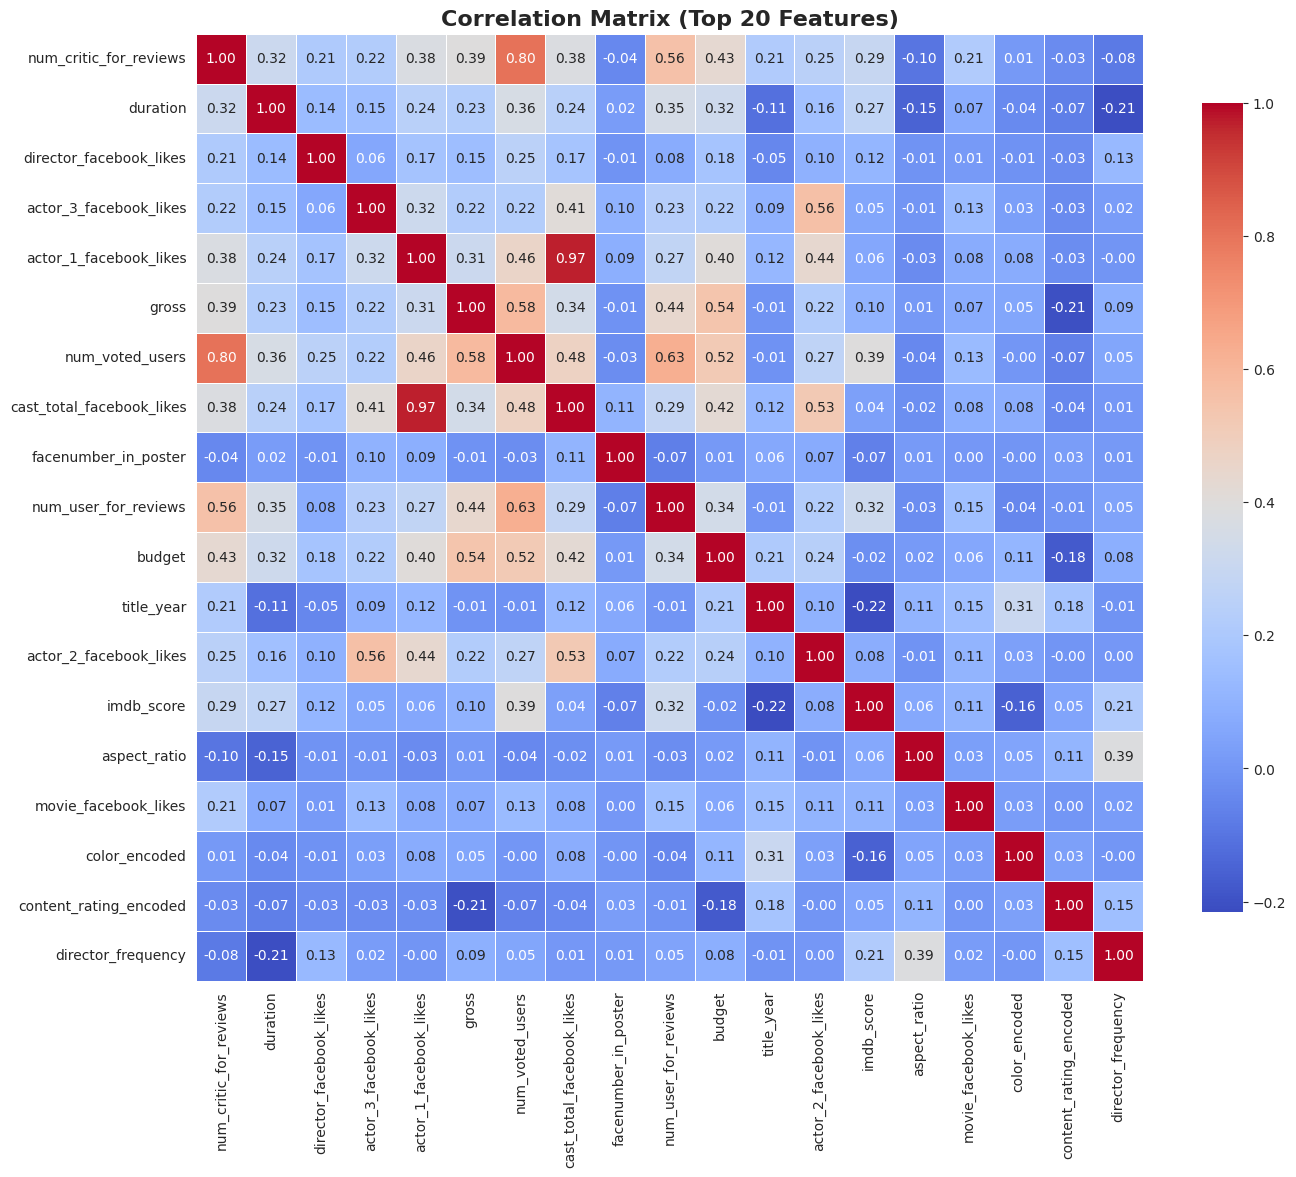

In [8]:
# Visualize correlation heatmap (top 20 features)
plt.figure(figsize=(14, 12))
top_features = df_numeric.columns[:20]
sns.heatmap(df_numeric[top_features].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix (Top 20 Features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


This code visualizes the correlation matrix of the top 20 numeric features using a heatmap. The heatmap illustrates the linear relationships between features, with color intensity and annotations indicating the strength and direction of these correlations. This helps in identifying highly correlated feature pairs.

### 3.3 Univariate Feature Selection (SelectKBest)

In [9]:
print("\n" + "="*70)
print("METHOD 3: UNIVARIATE FEATURE SELECTION (SelectKBest)")
print("="*70)
print("Selects top K features based on statistical tests\n")

# Define target variable (let's use imdb_score as target)
if 'imdb_score' in df_numeric.columns:
    target_col = 'imdb_score'
    X = df_numeric.drop(columns=[target_col])
    y = df_numeric[target_col]

    # Select top 20 features using F-statistic
    k_best = 20
    selector = SelectKBest(score_func=f_regression, k=k_best)
    X_kbest = selector.fit_transform(X, y)

    # Get selected feature names
    selected_features = X.columns[selector.get_support()].tolist()

    # Get feature scores
    feature_scores = pd.DataFrame({
        'Feature': X.columns,
        'Score': selector.scores_
    }).sort_values('Score', ascending=False)

    print(f"Target Variable: {target_col}")
    print(f"K (number of features to select): {k_best}")
    print(f"\nTop {k_best} features by F-statistic:")
    print(feature_scores.head(k_best).to_string(index=False))

    print(f"\nDataset shape after SelectKBest:")
    print(f"  Before: {X.shape}")
    print(f"  After: {X_kbest.shape}")
else:
    print("imdb_score not found in dataset")


METHOD 3: UNIVARIATE FEATURE SELECTION (SelectKBest)
Selects top K features based on statistical tests

Target Variable: imdb_score
K (number of features to select): 20

Top 20 features by F-statistic:
                  Feature      Score
          num_voted_users 925.064228
     num_user_for_reviews 576.369577
   num_critic_for_reviews 475.405016
                 duration 393.464431
               title_year 245.070652
       director_frequency 237.104666
            color_encoded 127.728180
  director_facebook_likes  69.692348
     movie_facebook_likes  57.367452
                    gross  52.943963
   actor_2_facebook_likes  33.149492
     facenumber_in_poster  22.910151
             aspect_ratio  19.525474
   actor_1_facebook_likes  17.498935
   actor_3_facebook_likes  13.626602
   content_rating_encoded  10.919127
cast_total_facebook_likes   6.311124
                   budget   2.368366

Dataset shape after SelectKBest:
  Before: (5043, 18)
  After: (5043, 18)


This cell applies univariate feature selection using `SelectKBest` with the F-regression test. It identifies the top 20 features that are most statistically significant in predicting the 'imdb_score' target variable. The output presents a ranked list of features based on their F-statistic scores and the dimensions of the dataset post-selection.

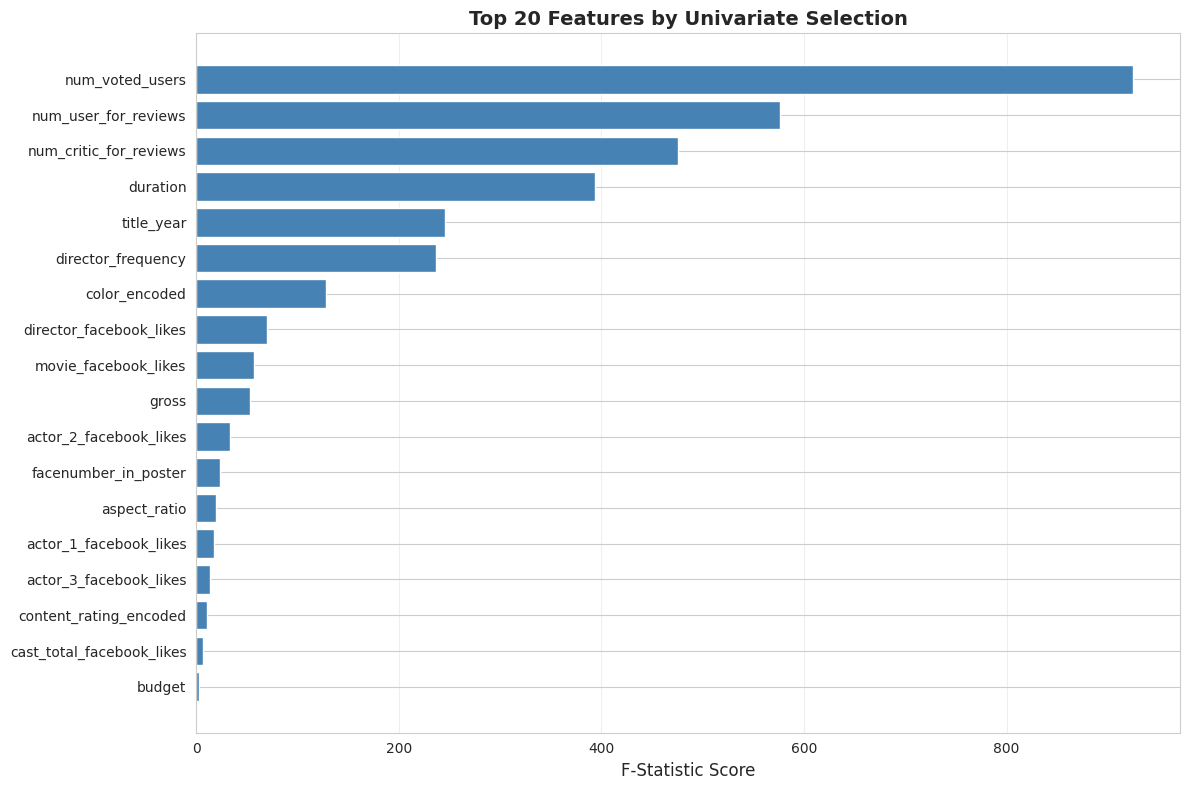

In [10]:
# Visualize feature importance
if 'imdb_score' in df_numeric.columns:
    plt.figure(figsize=(12, 8))
    top_20_scores = feature_scores.head(20)
    plt.barh(range(len(top_20_scores)), top_20_scores['Score'], color='steelblue')
    plt.yticks(range(len(top_20_scores)), top_20_scores['Feature'])
    plt.xlabel('F-Statistic Score', fontsize=12)
    plt.title('Top 20 Features by Univariate Selection', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


This cell generates a horizontal bar chart to visually represent the F-statistic scores of the top 20 features identified by univariate selection. Features with higher F-statistic scores are displayed with longer bars, indicating their stronger individual predictive power for the target variable.

### 3.4 Tree-Based Feature Importance

In [11]:
print("\n" + "="*70)
print("METHOD 4: TREE-BASED FEATURE IMPORTANCE")
print("="*70)
print("Uses Random Forest to rank feature importance\n")

if 'imdb_score' in df_numeric.columns:
    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)

    # Get feature importances
    rf_importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("Top 20 features by Random Forest importance:")
    print(rf_importances.head(20).to_string(index=False))

    # Select top K features
    k_rf = 20
    top_rf_features = rf_importances.head(k_rf)['Feature'].tolist()
    X_rf = X[top_rf_features]

    print(f"\nSelected top {k_rf} features")
    print(f"Dataset shape: {X_rf.shape}")


METHOD 4: TREE-BASED FEATURE IMPORTANCE
Uses Random Forest to rank feature importance

Top 20 features by Random Forest importance:
                  Feature  Importance
          num_voted_users    0.268150
                 duration    0.138105
                   budget    0.090817
               title_year    0.064559
                    gross    0.060964
     num_user_for_reviews    0.051558
   num_critic_for_reviews    0.048303
   actor_2_facebook_likes    0.040023
   actor_3_facebook_likes    0.037989
     movie_facebook_likes    0.036907
cast_total_facebook_likes    0.034152
  director_facebook_likes    0.032796
   actor_1_facebook_likes    0.028577
       director_frequency    0.021958
   content_rating_encoded    0.017138
     facenumber_in_poster    0.016813
             aspect_ratio    0.009043
            color_encoded    0.002149

Selected top 20 features
Dataset shape: (5043, 18)


This cell employs a tree-based method, specifically `RandomForestRegressor`, to assess feature importance. It trains a Random Forest model and then ranks features based on their contribution to the model's predictive accuracy. The top 20 most important features are identified, and a new dataset is created using only these features.

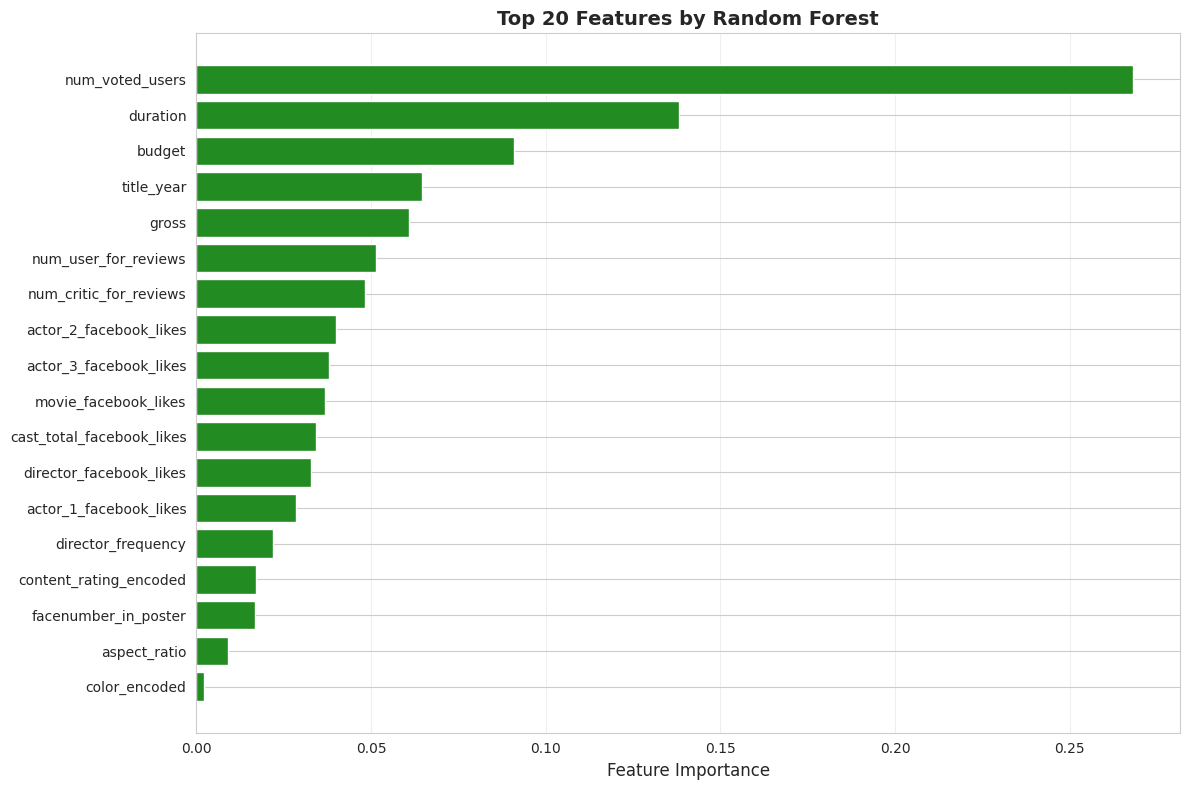

In [12]:
# Visualize Random Forest feature importance
if 'imdb_score' in df_numeric.columns:
    plt.figure(figsize=(12, 8))
    top_20_rf = rf_importances.head(20)
    plt.barh(range(len(top_20_rf)), top_20_rf['Importance'], color='forestgreen')
    plt.yticks(range(len(top_20_rf)), top_20_rf['Feature'])
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title('Top 20 Features by Random Forest', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


This cell displays a horizontal bar chart illustrating the relative importance of the top 20 features as determined by the Random Forest model. Features contributing more significantly to the model's predictions are represented by longer bars, providing a visual ranking of their impact.

## 4. Principal Component Analysis (PCA)

### 4.1 Apply PCA to Full Dataset

In [13]:
print("="*70)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*70)
print("\nPCA transforms features into uncorrelated principal components")
print("Each component captures maximum variance\n")

# Apply PCA with all components
pca_full = PCA()
pca_full.fit(df_numeric)

# Get explained variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Total components: {len(explained_variance)}")
print(f"\nVariance explained by first 10 components:")
for i in range(min(10, len(explained_variance))):
    print(f"  PC{i+1}: {explained_variance[i]*100:.2f}% (Cumulative: {cumulative_variance[i]*100:.2f}%)")

PRINCIPAL COMPONENT ANALYSIS (PCA)

PCA transforms features into uncorrelated principal components
Each component captures maximum variance

Total components: 19

Variance explained by first 10 components:
  PC1: 89.98% (Cumulative: 89.98%)
  PC2: 9.32% (Cumulative: 99.31%)
  PC3: 0.69% (Cumulative: 100.00%)
  PC4: 0.00% (Cumulative: 100.00%)
  PC5: 0.00% (Cumulative: 100.00%)
  PC6: 0.00% (Cumulative: 100.00%)
  PC7: 0.00% (Cumulative: 100.00%)
  PC8: 0.00% (Cumulative: 100.00%)
  PC9: 0.00% (Cumulative: 100.00%)
  PC10: 0.00% (Cumulative: 100.00%)


This cell initiates Principal Component Analysis (PCA) on the numeric dataset. It transforms the original features into a new set of uncorrelated principal components and then quantifies the proportion of total variance explained by each component. The cumulative explained variance for the initial ten components is also presented.

### 4.2 Visualize Explained Variance

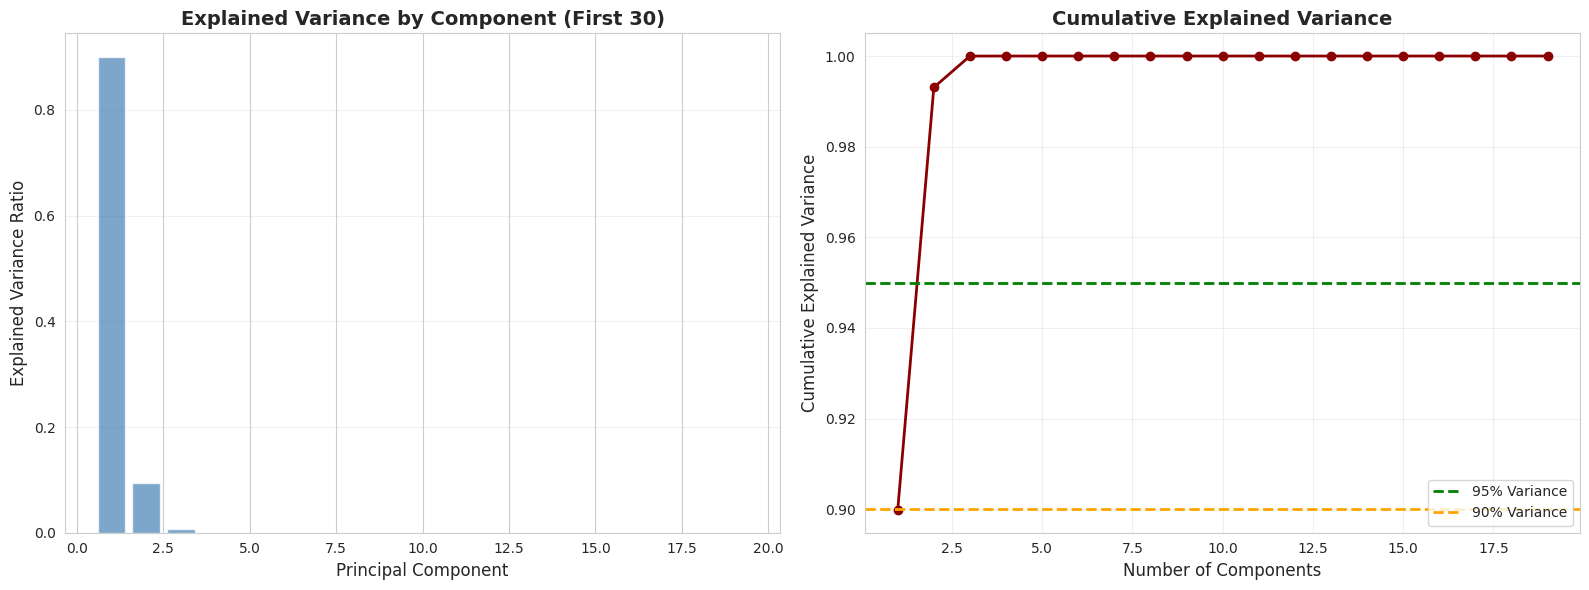

In [14]:
# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Individual explained variance
components = range(1, min(31, len(explained_variance) + 1))
axes[0].bar(components, explained_variance[:30], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Explained Variance by Component (First 30)',
                  fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Cumulative explained variance
axes[1].plot(components, cumulative_variance[:30],
            marker='o', linewidth=2, color='darkred')
axes[1].axhline(y=0.95, color='green', linestyle='--',
               label='95% Variance', linewidth=2)
axes[1].axhline(y=0.90, color='orange', linestyle='--',
               label='90% Variance', linewidth=2)
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance',
                 fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


This cell visualizes the explained variance by PCA. The first plot shows the individual variance explained by each of the first 30 principal components. The second plot illustrates the cumulative explained variance, indicating how much total information is retained as more components are included, with reference lines at 90% and 95% for determining the optimal number of components.

### 4.3 Determine Optimal Number of Components

In [15]:
# Find number of components for different variance thresholds
variance_thresholds = [0.80, 0.85, 0.90, 0.95, 0.99]

print("\n" + "="*70)
print("OPTIMAL NUMBER OF COMPONENTS")
print("="*70)
print("\nComponents needed to explain variance:")
print("-" * 70)

for threshold in variance_thresholds:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    reduction = (1 - n_components/len(explained_variance)) * 100
    print(f"{threshold*100:.0f}% variance: {n_components:3d} components "
          f"(Reduction: {reduction:.1f}%)")

# Select 95% variance as optimal
optimal_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\n Selected: {optimal_components} components (95% variance)")


OPTIMAL NUMBER OF COMPONENTS

Components needed to explain variance:
----------------------------------------------------------------------
80% variance:   1 components (Reduction: 94.7%)
85% variance:   1 components (Reduction: 94.7%)
90% variance:   2 components (Reduction: 89.5%)
95% variance:   2 components (Reduction: 89.5%)
99% variance:   2 components (Reduction: 89.5%)

 Selected: 2 components (95% variance)


This cell identifies the optimal number of principal components needed to retain a significant portion of the dataset's variance. It calculates how many components are required to explain 80%, 85%, 90%, 95%, and 99% of the total variance, ultimately selecting the number of components that preserve at least 95% of the variance.

### 4.4 Apply PCA with Optimal Components

In [16]:
# Apply PCA with optimal number of components
pca_optimal = PCA(n_components=optimal_components)
df_pca = pca_optimal.fit_transform(df_numeric)

# Create DataFrame with PCA results
pca_columns = [f'PC{i+1}' for i in range(optimal_components)]
df_pca_result = pd.DataFrame(df_pca, columns=pca_columns)

print("\n" + "="*70)
print("PCA TRANSFORMATION COMPLETE")
print("="*70)
print(f"\nOriginal shape: {df_numeric.shape}")
print(f"PCA shape: {df_pca_result.shape}")
print(f"Dimensionality reduction: {df_numeric.shape[1]} → {optimal_components}")
print(f"Variance preserved: {cumulative_variance[optimal_components-1]*100:.2f}%")
print(f"\nFirst 5 rows of PCA-transformed data:")
df_pca_result.head()


PCA TRANSFORMATION COMPLETE

Original shape: (5043, 19)
PCA shape: (5043, 2)
Dimensionality reduction: 19 → 2
Variance preserved: 99.31%

First 5 rows of PCA-transformed data:


,PC1,PC2
0,-578.694509,477.242765
1,3352.937986,-464.124200
2,-1321.432970,-127.301455
3,26316.200402,16348.325815
4,-1655.114533,143.706412


This cell reapplies PCA using the previously determined optimal number of components. It transforms the original numeric dataset into a lower-dimensional space, creating a new DataFrame `df_pca_result`. The output verifies the dimensionality reduction achieved and confirms the percentage of variance preserved by this transformation, along with a preview of the transformed data.

### 4.5 Visualize PCA Components

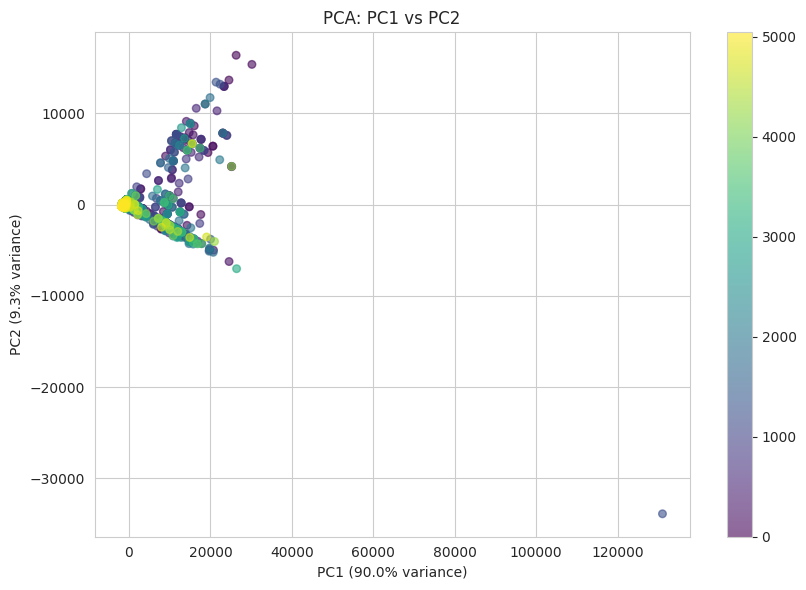

In [17]:
# PCA Visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PC1 vs PC2
scatter = axes[0].scatter(
    df_pca[:, 0], df_pca[:, 1],
    c=range(len(df_pca)),
    cmap='viridis',
    alpha=0.6,
    s=30
)

axes[0].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}% variance)')
axes[0].set_title('PCA: PC1 vs PC2')
axes[0].grid(True)

plt.colorbar(scatter, ax=axes[0])


# Plot 2: Only if PC3 exists
if df_pca.shape[1] >= 3:
    scatter2 = axes[1].scatter(
        df_pca[:, 0], df_pca[:, 2],
        c=range(len(df_pca)),
        cmap='plasma',
        alpha=0.6,
        s=30
    )

    axes[1].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}% variance)')
    axes[1].set_ylabel(f'PC3 ({explained_variance[2]*100:.1f}% variance)')
    axes[1].set_title('PCA: PC1 vs PC3')
    axes[1].grid(True)

    plt.colorbar(scatter2, ax=axes[1])
else:
    axes[1].set_visible(False)


plt.tight_layout()
plt.show()

This cell visualizes the PCA-transformed data by plotting the principal components against each other. The first subplot shows the distribution of data points in the space defined by PC1 and PC2. If a third principal component exists, the second subplot illustrates the relationship between PC1 and PC3, helping to understand data separation and patterns in the reduced dimensions.

### 4.6 Component Loadings (Feature Contributions)

In [18]:
# Get component loadings (top 5 PCs)
n_show = min(5, optimal_components)
components_df = pd.DataFrame(
    pca_optimal.components_[:n_show],
    columns=df_numeric.columns,
    index=[f'PC{i+1}' for i in range(n_show)]
)

print("\n" + "="*70)
print(f"TOP FEATURES CONTRIBUTING TO FIRST {n_show} PRINCIPAL COMPONENTS")
print("="*70)

for i in range(n_show):
    pc_name = f'PC{i+1}'
    loadings = components_df.loc[pc_name].abs().sort_values(ascending=False)
    print(f"\n{pc_name} (Variance: {explained_variance[i]*100:.2f}%):")
    print("  Top 5 features:")
    for j, (feature, loading) in enumerate(loadings.head(5).items(), 1):
        print(f"    {j}. {feature:40s}: {loading:.4f}")


TOP FEATURES CONTRIBUTING TO FIRST 2 PRINCIPAL COMPONENTS

PC1 (Variance: 89.98%):
  Top 5 features:
    1. actor_2_facebook_likes                  : 0.9679
    2. actor_3_facebook_likes                  : 0.2505
    3. num_user_for_reviews                    : 0.0210
    4. title_year                              : 0.0003
    5. cast_total_facebook_likes               : 0.0001

PC2 (Variance: 9.32%):
  Top 5 features:
    1. actor_3_facebook_likes                  : 0.9674
    2. actor_2_facebook_likes                  : 0.2511
    3. num_user_for_reviews                    : 0.0337
    4. title_year                              : 0.0004
    5. facenumber_in_poster                    : 0.0001


This cell analyzes the component loadings, which indicate the contribution of each original feature to the newly formed principal components. For the first five principal components, it identifies and lists the top five features that have the strongest influence or correlation with each respective component, aiding in the interpretation of the components' meaning.

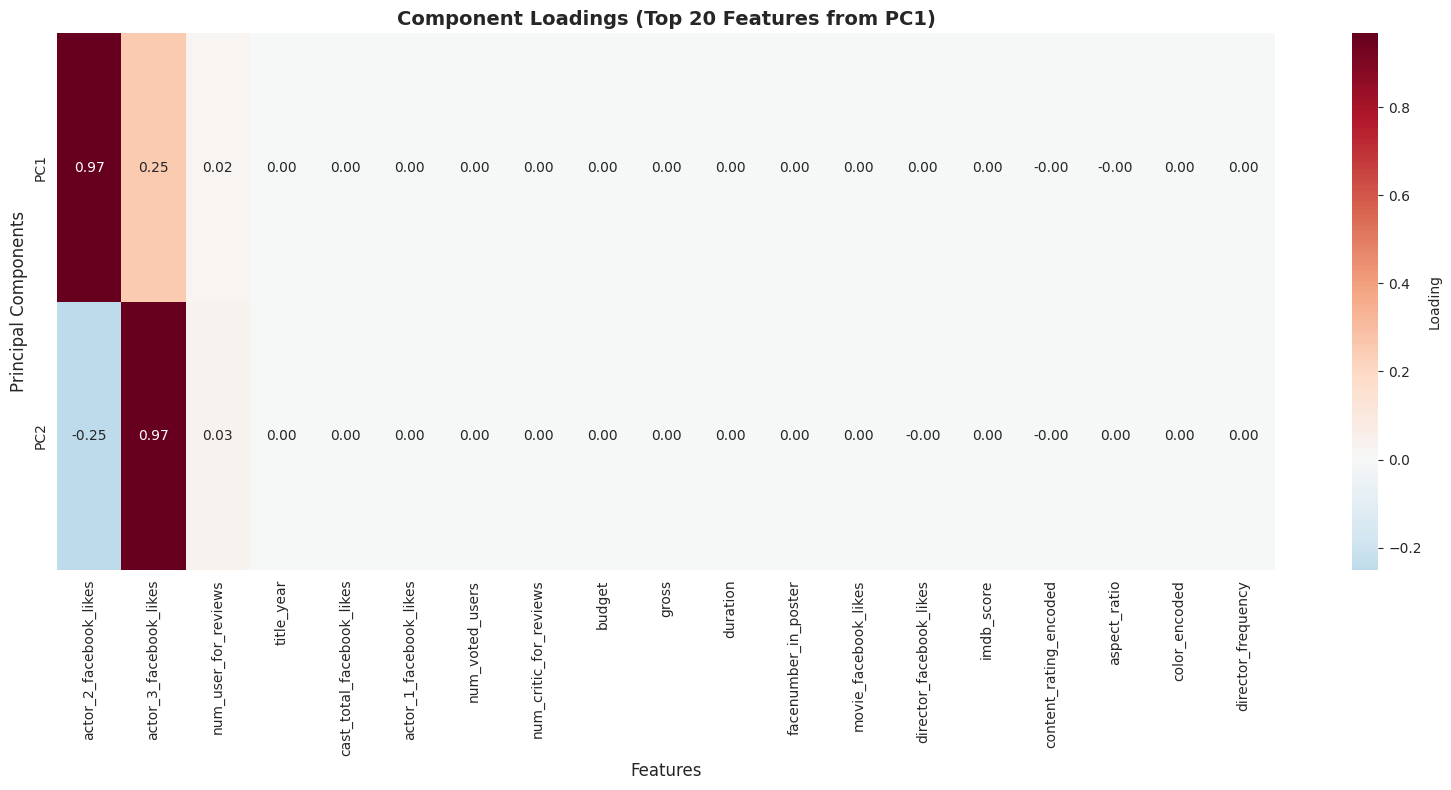

In [19]:
# Visualize component loadings heatmap
plt.figure(figsize=(16, 8))

# Select top 20 features by absolute loading on PC1
top_features_pc1 = components_df.loc['PC1'].abs().nlargest(20).index
loadings_subset = components_df[top_features_pc1]

sns.heatmap(loadings_subset, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', cbar_kws={'label': 'Loading'})
plt.title(f'Component Loadings (Top 20 Features from PC1)',
         fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Principal Components', fontsize=12)
plt.tight_layout()
plt.show()


This cell provides a heatmap visualization of the component loadings, specifically focusing on the top 20 features that exhibit the highest absolute contribution to the first principal component (PC1). This heatmap helps in understanding which original features are most strongly associated with the primary directions of variance captured by PCA.

## 5. Save Reduced Datasets

In [20]:
# Save PCA-transformed dataset
df_pca_result.to_csv('movie_metadata_pca.csv', index=False)

# Save feature-selected dataset (using Random Forest top features)
if 'imdb_score' in df_numeric.columns:
    df_selected = X[top_rf_features].copy()
    df_selected['imdb_score'] = y  # Add target back
    df_selected.to_csv('movie_metadata_selected_features.csv', index=False)

# Save combined dataset (PCA + selected important features)
if 'imdb_score' in df_numeric.columns:
    df_combined = df_pca_result.copy()
    df_combined['imdb_score'] = y.values
    # Add a few most important original features
    top_3_features = top_rf_features[:3]
    for feat in top_3_features:
        df_combined[feat] = X[feat].values
    df_combined.to_csv('movie_metadata_reduced.csv', index=False)


This cell exports the dimensionality-reduced datasets into CSV files for future use. It saves the PCA-transformed data, the feature-selected data (based on Random Forest importance), and a combined dataset incorporating both PCA components and selected important original features, alongside the target variable.

## 6. Comparison Summary

In [21]:
print("\n" + "="*70)
print("DIMENSIONALITY REDUCTION SUMMARY")
print("="*70)

summary_data = [
    {
        'Method': 'Original Dataset',
        'Features': df_numeric.shape[1],
        'Samples': df_numeric.shape[0],
        'Description': 'All features'
    },
    {
        'Method': 'Variance Threshold',
        'Features': df_var_threshold.shape[1],
        'Samples': df_var_threshold.shape[0],
        'Description': f'Removed {removed_features} low-variance features'
    },
    {
        'Method': 'Correlation Filter',
        'Features': df_low_corr.shape[1],
        'Samples': df_low_corr.shape[0],
        'Description': f'Removed {len(to_drop)} highly correlated features'
    }
]

if 'imdb_score' in df_numeric.columns:
    summary_data.extend([
        {
            'Method': f'SelectKBest (k={k_best})',
            'Features': X_kbest.shape[1],
            'Samples': X_kbest.shape[0],
            'Description': 'Top features by F-statistic'
        },
        {
            'Method': f'Random Forest (k={k_rf})',
            'Features': X_rf.shape[1],
            'Samples': X_rf.shape[0],
            'Description': 'Top features by importance'
        }
    ])

summary_data.append({
    'Method': f'PCA ({optimal_components} components)',
    'Features': df_pca_result.shape[1],
    'Samples': df_pca_result.shape[0],
    'Description': f'{cumulative_variance[optimal_components-1]*100:.1f}% variance preserved'
})

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*70)



DIMENSIONALITY REDUCTION SUMMARY

              Method  Features  Samples                          Description
    Original Dataset        19     5043                         All features
  Variance Threshold        18     5043      Removed 1 low-variance features
  Correlation Filter        18     5043 Removed 1 highly correlated features
  SelectKBest (k=20)        18     5043          Top features by F-statistic
Random Forest (k=20)        18     5043           Top features by importance
  PCA (2 components)         2     5043             99.3% variance preserved



This cell generates a comprehensive summary table comparing the outcomes of the various dimensionality reduction techniques applied in this notebook. It provides a concise overview of each method, detailing the resulting number of features and samples, along with a brief description of the approach taken for feature reduction.